In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import Counter
import random
import numpy as np
import math
from pathlib import Path

import nltk
from nltk.corpus import stopwords
import string

import matplotlib.pyplot as plt

In [2]:
# Ensure the data is there
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tânia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# -----------------------------
# 1. Sample corpus
# -----------------------------
#!python prep_fairytales.py --indir ./raw_fairytales --outdir corpus --lower --dedup
!python prep_fairytales.py --urls urls_tales.txt --outdir corpus --lower --dedup

Fetched https://www.gutenberg.org/cache/epub/503/pg503.txt
Fetched https://www.gutenberg.org/cache/epub/27200/pg27200.txt
Fetched https://www.gutenberg.org/cache/epub/2591/pg2591.txt
Fetched https://www.gutenberg.org/cache/epub/17034/pg17034.txt
Fetched https://www.gutenberg.org/cache/epub/37532/pg37532.txt
Fetched https://www.gutenberg.org/cache/epub/7439/pg7439.txt
{
  "stories": 6,
  "tokens": 792983,
  "vocab": 19122,
  "removed_non_english": 0,
  "generated_at": "2026-02-23T15:56:10.509072Z"
}
✔ Wrote 6 stories to corpus\clean


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tânia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
c:\Users\Tânia\Work\word2vec\prep_fairytales.py:233: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat() + "Z",


In [4]:
def iter_tokens(tokens_path: Path):
    with tokens_path.open("r", encoding="utf-8") as f:
        for line in f:
            yield line.strip().split()

tokens_path = Path('.\\corpus\\clean\\corpus.txt')
tokenized_corpus = list(iter_tokens(tokens_path))

In [5]:
# 1. Preprocessing with Min-Count Filtering
def prepare_data(tokenized_corpus, min_count=5):
    # Count frequencies
    word_counts = Counter([word for sentence in tokenized_corpus for word in sentence])
    # Filter vocab
    vocab = {word: count for word, count in word_counts.items() if count >= min_count}
    word2idx = {word: idx for idx, word in enumerate(vocab.keys())}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    # Filter sentences to only include words in the new vocab
    filtered_corpus = [[w for w in s if w in word2idx] for s in tokenized_corpus]
    return filtered_corpus, word2idx, idx2word, len(word2idx)

In [6]:
def get_refined_stopwords():
    # 1. Start with NLTK defaults
    stop_words = set(stopwords.words('english'))
    
    # 2. Add common missing tokens/conjunctions
    extra_stops = {'at', 'if', 'on', 'the', 'is', 'it', 'to', 'and', 'a'} 
    stop_words.update(extra_stops)
    
    # 3. Add punctuation (often missed if not handled separately)
    stop_words.update(list(string.punctuation))
    
    # 4. Optional: Add "Fairytale" specific noise
    # Since you're prepping fairytales, words like "said" or "upon" 
    # might be so frequent they act like stop words.
    stop_words.update(['said', 'upon', 'would', 'could'])
    
    return stop_words

In [7]:
def prepare_data_v2(tokenized_corpus, min_count=5, threshold=1e-3):
    # Flatten for counting
    all_tokens = [word for sentence in tokenized_corpus for word in sentence]
    word_counts = Counter(all_tokens)
    total_count = len(all_tokens)
    
    # 1.1 Stopword list (highly recommended for analogies on small data)
    stop_words = get_refined_stopwords()

    # 1.2 Subsampling logic: P(w) = 1 - sqrt(threshold / frequency)
    # This keeps rare words and downsamples common ones
    def should_keep(word):
        word_lower = word.lower()

        if word_lower in stop_words: return False # Optional: hard filter
        if word_counts[word_lower] < min_count: return False
        if word_counts[word_lower] < min_count: return False

        freq = word_counts[word_lower] / total_count
        prob = 1 - math.sqrt(threshold / freq)
        return random.random() > prob

    filtered_corpus = []
    for sentence in tokenized_corpus:
        filtered_sentence = [w for w in sentence if should_keep(w)]
        if len(filtered_sentence) > 1:
            filtered_corpus.append(filtered_sentence)

    # Rebuild Vocab
    new_counts = Counter([w for s in filtered_corpus for w in s])
    word2idx = {word: idx for idx, word in enumerate(new_counts.keys())}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    return filtered_corpus, word2idx, idx2word, len(word2idx), new_counts

In [8]:
# 2. Skip-gram Data Generation
def generate_skipgram_data(tokenized_corpus, word2idx, window_size=10):
    pairs = []
    for sentence in tokenized_corpus:
        indices = [word2idx[w] for w in sentence]
        for center_idx, center_word in enumerate(indices):
            context_range = range(max(0, center_idx - window_size), 
                                  min(len(indices), center_idx))
            for context_idx in context_range:
                if context_idx != center_idx:
                    pairs.append((center_word, indices[context_idx]))
    return pairs

In [9]:
# 3. Optimized Model using Dot Product
class Word2VecSGNS(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(Word2VecSGNS, self).__init__()
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)
        # Initialize weights to small values
        initrange = 0.5 / embedding_dim
        self.in_embed.weight.data.uniform_(-initrange, initrange)
        self.out_embed.weight.data.uniform_(-0, 0)

    def forward(self, center_words, pos_words, neg_words):
        # center: (batch), pos: (batch), neg: (batch, num_neg)
        
        v = self.in_embed(center_words).unsqueeze(2)    # (batch, dim, 1)
        u_pos = self.out_embed(pos_words).unsqueeze(1) # (batch, 1, dim)
        u_neg = self.out_embed(neg_words)              # (batch, num_neg, dim)

        # Log-sigmoid loss for positive pairs (Dot product)
        pos_score = torch.bmm(u_pos, v).squeeze()      # (batch)
        pos_loss = F.logsigmoid(pos_score)

        # Log-sigmoid loss for negative pairs
        neg_score = torch.bmm(u_neg, v).squeeze()      # (batch, num_neg)
        neg_loss = F.logsigmoid(-neg_score).sum(1)     # Sum over negative samples

        return -(pos_loss + neg_loss).mean()

In [10]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Ensures deterministic behavior in some PyTorch operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [11]:
def create_negative_sampling_table(new_counts, word2idx, table_size=10**6):
    # Ensure counts are in the correct index order
    counts = np.array([new_counts[w] for w, i in sorted(word2idx.items(), key=lambda x: x[1])])
    
    # Apply the 3/4 power rule
    pow_counts = np.power(counts, 0.75)
    probs = pow_counts / np.sum(pow_counts)
    
    # Pre-generate table for O(1) lookup
    return np.random.choice(len(word2idx), size=table_size, p=probs)

In [12]:
# 4. Training with Learning Rate Scheduler
def train_model(model, training_pairs, vocab_size, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    # Decay learning rate so the model 'settles' into precise relationships
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    batch_size = 1024
    num_negatives = 10
    epoch_loss = []

    # Pointer to track our position in the pre-generated table
    table_ptr = 0
    table_size = len(neg_table)

    for epoch in range(epochs):
        random.shuffle(training_pairs)
        total_loss = 0
        
        for i in range(0, len(training_pairs), batch_size):
            batch = training_pairs[i:i+batch_size]
            if len(batch) < batch_size: continue
        
            centers = torch.LongTensor([c for c, p in batch])
            positives = torch.LongTensor([p for c, p in batch])
            
            # -- old negative sampling
            #negatives = torch.randint(0, vocab_size, (batch_size, num_negatives))
            
            # --- IMPROVED NEGATIVE SAMPLING ---
            # Instead of torch.randint, we pull from our 3/4 power table
            # We flatten the selection to make it fast
            if table_ptr + (batch_size * num_negatives) > table_size:
                table_ptr = 0 # Reset pointer if we reach the end
            
            neg_indices = neg_table[table_ptr : table_ptr + (batch_size * num_negatives)]
            negatives = torch.LongTensor(neg_indices).view(batch_size, num_negatives)
            table_ptr += (batch_size * num_negatives)
            # ----------------------------------

            optimizer.zero_grad()
            loss = model(centers, positives, negatives)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(training_pairs):.6f}, LR: {scheduler.get_last_lr()[0]:.5f}")

        epoch_loss.append(total_loss)
    torch.save(model, "word2vect_tania_sgns.pt")
    return epoch_loss

In [13]:
# 5. Training Loop
# Assuming tokenized_corpus is already loaded from your previous cell
filtered_corpus, word2idx, idx2word, vocab_size, counter = prepare_data_v2(tokenized_corpus, min_count=5)
training_pairs = generate_skipgram_data(filtered_corpus, word2idx,20)

embedding_dim = 50 
model = Word2VecSGNS(vocab_size, embedding_dim)
epochs = 75

neg_table = create_negative_sampling_table(counter, word2idx)

In [14]:
vocab_size

7102

In [15]:
counter

Counter({'little': 1800,
         'one': 1779,
         'came': 1427,
         'went': 1385,
         'old': 1370,
         'man': 1230,
         'like': 1212,
         'great': 1206,
         'king': 1204,
         'time': 1168,
         'see': 1157,
         'away': 1133,
         'go': 1103,
         'well': 1099,
         'must': 1059,
         'come': 1054,
         'good': 1049,
         'day': 1049,
         'thought': 1029,
         'saw': 1002,
         'long': 1001,
         'shall': 983,
         'two': 979,
         'beautiful': 971,
         'made': 968,
         'mother': 958,
         'back': 954,
         'last': 946,
         'never': 943,
         'took': 942,
         'house': 935,
         'home': 931,
         'young': 929,
         'much': 919,
         'looked': 906,
         'quite': 893,
         'till': 868,
         'princess': 866,
         'head': 842,
         'father': 830,
         'still': 828,
         'prince': 821,
         'way': 803,
         'ever

In [16]:
neg_table

array([ 904, 6271, 3220, ..., 1076, 1108, 5864],
      shape=(1000000,), dtype=int32)

In [17]:
epoch_loss = train_model(model,training_pairs,vocab_size,epochs)

Epoch 10, Loss: 0.002961, LR: 0.00191
Epoch 20, Loss: 0.002952, LR: 0.00167
Epoch 30, Loss: 0.002944, LR: 0.00131
Epoch 40, Loss: 0.002934, LR: 0.00090
Epoch 50, Loss: 0.002925, LR: 0.00050
Epoch 60, Loss: 0.002917, LR: 0.00019
Epoch 70, Loss: 0.002912, LR: 0.00002


Text(0.5, 1.0, 'Training Loss Curve')

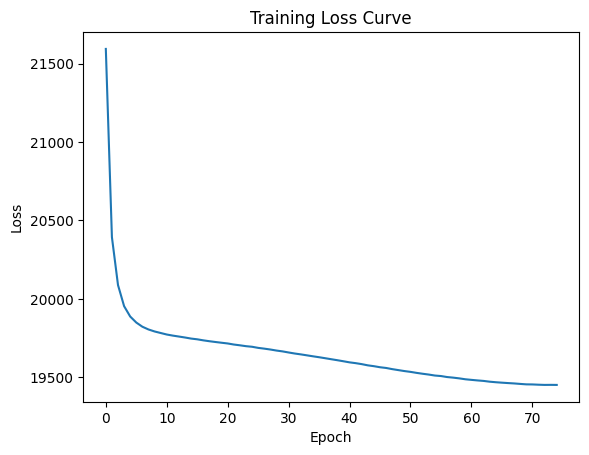

In [21]:
#plotting the loss curve
plt.plot(epoch_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')

In [22]:
model = torch.load("word2vect_tania_sgns.pt",map_location='cpu',weights_only=False)

In [23]:
# 6. Evaluation Function (Cosine Similarity for Inference only)
def find_similar(word, top_n=5):
    if word not in word2idx: return "Not in vocab"
    
    # Use 'in' embeddings for similarity
    weights = model.in_embed.weight.data
    query_vec = weights[word2idx[word]]
    
    # Cosine similarity: (A dot B) / (||A|| * ||B||)
    cos_sim = F.cosine_similarity(query_vec.unsqueeze(0), weights)
    
    scores, indices = torch.topk(cos_sim, top_n + 1)
    for i in range(1, len(indices)): # skip the word itself
        print(f"{idx2word[indices[i].item()]}: {scores[i].item():.4f}")

print("\nResults for 'king':")
find_similar("king")


Results for 'king':
daughter: 0.6323
ordered: 0.6293
queen: 0.6131
kingdom: 0.6096
begged: 0.5993


In [24]:
find_similar("cat")

mouse: 0.6274
puss: 0.5847
dog: 0.5397
tail: 0.5303
mistress: 0.5280


In [25]:
def find_similar_embedding(positive, negative, top_n=5):
    positive_negative = positive + negative
    cos = nn.CosineSimilarity(dim=0, eps=1e-6)

    weights = model.in_embed.weight.data

    for item in positive_negative:
        if item not in word2idx:
            print(f"{item} not in vocabulary")

    query_vec = weights[word2idx[positive[0]]] - weights[word2idx[negative[0]]] + weights[word2idx[positive[1]]]
    
    # Compute cosine similarity with all other words
    similarities = {}
    for word, idx in word2idx.items():
        if word not in positive_negative:
            
            sim = cos(query_vec,weights[idx])
            similarities[word] = sim
    
    # Sort by similarity
    similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    print(f"\nTop {top_n} words similar to embedding:")
    for word, score in similar_words:
        print(f"{word}: {score:.4f}")

In [26]:
find_similar_embedding(positive = ['king','woman'], negative = ['man'], top_n=5)


Top 5 words similar to embedding:
queen: 0.5865
happily: 0.5604
promised: 0.5093
glad: 0.4976
vain: 0.4759


In [27]:
find_similar_embedding(positive = ['father','woman'], negative = ['man'], top_n=5)


Top 5 words similar to embedding:
child: 0.5863
mother: 0.5716
awhile: 0.5622
wept: 0.5574
glad: 0.5534


In [28]:
find_similar_embedding(positive = ['brother','woman'], negative = ['man'], top_n=5)


Top 5 words similar to embedding:
sister: 0.5650
frightening: 0.5203
gathering: 0.5110
awhile: 0.5026
brethren: 0.5011


In [29]:
find_similar_embedding(positive = ['cats','mouse'], negative = ['cat'], top_n=5)


Top 5 words similar to embedding:
mice: 0.5445
bronze: 0.5319
cups: 0.5051
cruelty: 0.4938
sentry: 0.4894
